### Census Income Classification: Understanding Income Inequality
### Predicting whether a US citizen earns above or below $50K using K-Nearest Neighbors

**Dataset:** UCI Adult Census Data (42,468 records, 14 features)  
**Objective:** Classify low income (<=50K) vs high income (>50K) to identify attributes that contribute to affluency and inform policy decisions.

In [13]:
import pandas as pd
import numpy as np

#### Part 1: Data Collection & Cleaning
**Step 1: Import Libraries and Load Data**

The dataset encodes missing values as `?`. This is handled at load time using `na_values=' ?'`, and column names are assigned manually since the raw file contains no header row.

In [14]:
# Load the dataset
col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'salary'
]

df = pd.read_csv('adult-all.csv', names=col_names, na_values=' ?', skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Step 2: Drop Irrelevant Column and Check for Missing Values**

`fnlwgt` is a Census Bureau sampling weight with no predictive value for income classification and is explicitly marked to ignore. A missing value check confirms no null values are present in this dataset.

In [15]:
# Preprocess the data
df.drop(columns=['fnlwgt'], inplace=True)

# Handle missing values
df.isnull().sum()
df.isnull().mean() * 100  

age               0.0
workclass         0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
salary            0.0
dtype: float64

**Step 3: Remove Duplicates and Resolve Redundant Features**

`education` and `education-num` carry identical information. Keeping both would double-weight education in the model. The categorical version is dropped and the numeric encoding is retained, as KNN requires numeric inputs.

In [16]:
# Duplicate rows
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Handle education and education-num
df.drop(columns=['education'], inplace=True)

# check for outliers
df[['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,42468.000000,42468.000000,42468.000000,42468.000000,42468.000000
mean,39.476947,10.094801,1226.217128,99.859212,40.650702
std,13.779595,2.658658,7931.500736,429.072095,12.867960
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,29.000000,9.000000,0.000000,0.000000,38.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,49.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


**Step 4: Detect Outliers**

The IQR method is applied to quantify outliers across all continuous variables. Any value below Q1 - 1.5×IQR or above Q3 + 1.5×IQR is flagged as an outlier.

In [17]:
continuous_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outlier_count} outliers ({outlier_count/len(df)*100:.1f}%)")

age: 184 outliers (0.4%)
education-num: 323 outliers (0.8%)
capital-gain: 3997 outliers (9.4%)
capital-loss: 2265 outliers (5.3%)
hours-per-week: 9260 outliers (21.8%)


**Step 5: Treat Outliers**

`capital-gain` (9.4%) and `capital-loss` (5.3%) show extreme right skew that would distort KNN distance calculations. Both are capped at the 99th percentile to reduce the influence of extreme values while retaining all rows. `hours-per-week` at 21.8% is left unchanged, as non-standard working hours represent a legitimate real-world pattern rather than data errors.

In [18]:
# Cap capital-gain and capital-loss at 99th percentile
for col in ['capital-gain', 'capital-loss']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

# Verify
print(df[['capital-gain', 'capital-loss']].describe())

       capital-gain  capital-loss
count  42468.000000  42468.000000
mean     710.883983     96.184963
std     2653.349590    409.495158
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max    15024.000000   2002.000000


**Step 6: Encode the Target Variable**

The salary column is converted to binary: 0 for <=50K and 1 for >50K. The class distribution reveals an imbalance of approximately 75% vs 25%, which informs the use of `stratify` during the train/test split.

In [19]:
# Encode the Target Variable
df['salary'] = df['salary'].str.strip().map({'<=50K': 0, '>50K': 1})

# Verify
print(df['salary'].value_counts())
print(df['salary'].value_counts(normalize=True) * 100)

salary
0    32020
1    10448
Name: count, dtype: int64
salary
0    75.397947
1    24.602053
Name: proportion, dtype: float64


**Step 7: One-Hot Encode Categorical Features**

KNN cannot compute distances on string values. One-hot encoding is applied to all nominal categorical columns. `drop_first=True` removes one category per variable to avoid the dummy variable trap, expanding the feature space from 13 to 84 columns.

In [20]:
categorical_cols = ['workclass', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.shape)
print(df.head())

(42468, 85)
   age  education-num  capital-gain  capital-loss  hours-per-week  salary  \
0   39             13          2174             0              40       0   
1   50             13             0             0              13       0   
2   38              9             0             0              40       0   
3   53              7             0             0              40       0   
4   28             13             0             0              40       0   

   workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  \
0                  False                False                   False   
1                  False                False                   False   
2                  False                False                   False   
3                  False                False                   False   
4                  False                False                   False   

   workclass_Private  ...  native-country_Portugal  \
0              False  ...       

**Step 8: Scale Features and Split Data**

Feature scaling is essential for KNN. Without it, variables with large numeric ranges (e.g. capital-gain up to 15,024) would dominate the distance calculation over variables with small ranges (e.g. education-num, 1 to 16). `stratify=y` is used to preserve the 75/25 class ratio across both train and test sets.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['salary'])
y = df['salary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 33974, Test size: 8494


#### Part 2: KNN Model
**Step 9: Choose K Using Cross-Validation (Elbow Method)**

Odd values of K from 1 to 30 are tested using 5-fold cross-validation. Odd values are chosen to prevent ties in majority voting. Accuracy is plotted against K and the optimal value is selected at the elbow point where accuracy stops improving meaningfully. A small K overfits to noise; a large K underfits by over-smoothing the decision boundary.

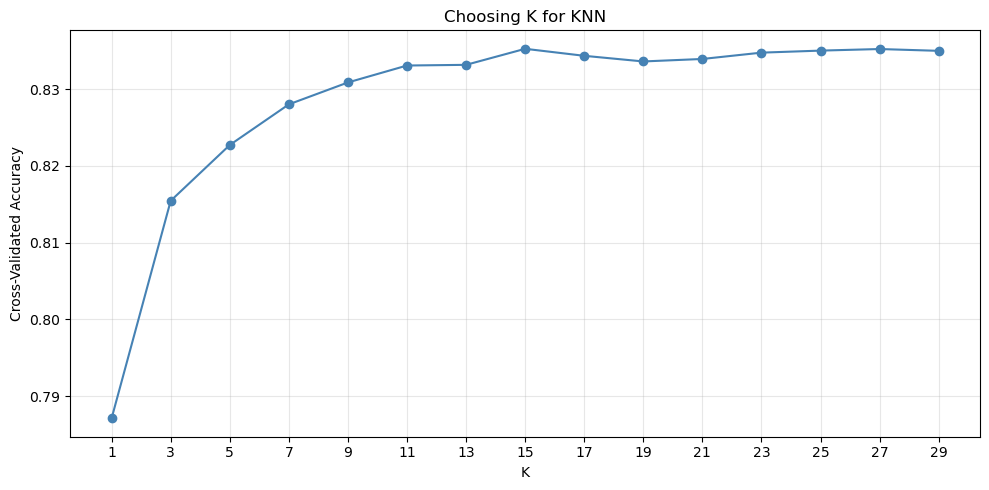

Best K: 15, Accuracy: 0.8353


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

k_values = range(1, 31, 2)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', color='steelblue')
plt.xlabel('K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Choosing K for KNN')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('k_selection.png', dpi=150)
plt.show()

best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"Best K: {best_k}, Accuracy: {max(cv_scores):.4f}")

**Step 10: Train Final KNN Model and Evaluate**

Using the optimal K identified above, the final model is trained and evaluated using a classification report, confusion matrix, and AUC score. Because the classes are imbalanced (75/25), F1-score is a more reliable performance metric than accuracy alone.

              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89      6404
        >50K       0.69      0.55      0.61      2090

    accuracy                           0.83      8494
   macro avg       0.78      0.73      0.75      8494
weighted avg       0.82      0.83      0.82      8494

AUC: 0.8748


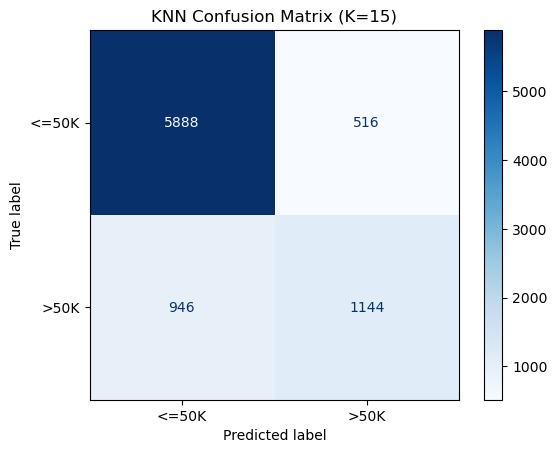

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

**Step 11: Feature Importance via Permutation**

KNN has no built-in coefficients or feature weights. Permutation importance is used instead: each feature is shuffled one at a time and the resulting drop in accuracy is measured. A large drop indicates the model relied heavily on that feature.

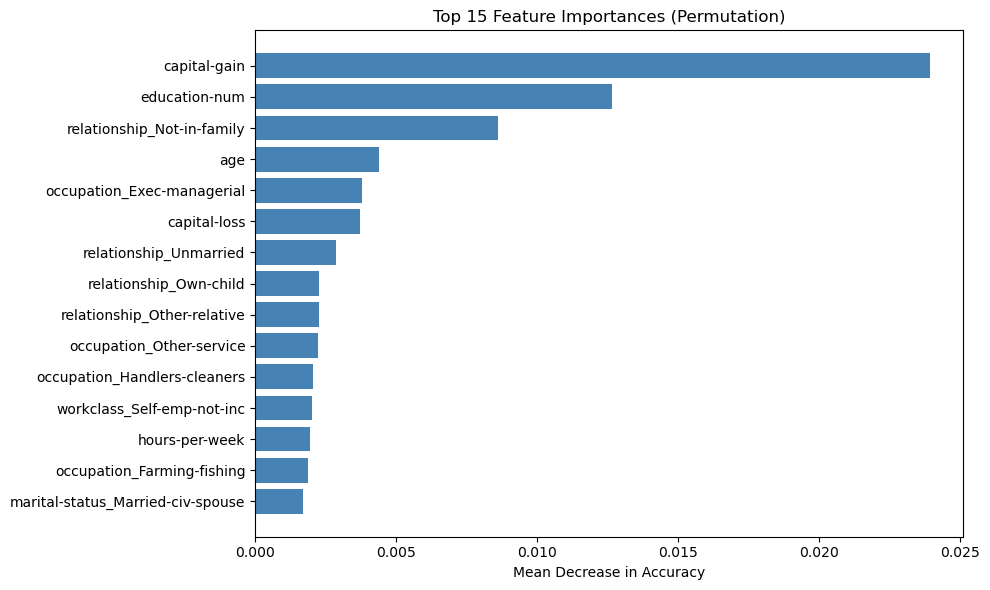

In [24]:
from sklearn.inspection import permutation_importance

result = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

feature_names = df.drop(columns=['salary']).columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='steelblue')
plt.xlabel('Mean Decrease in Accuracy')
plt.title('Top 15 Feature Importances (Permutation)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

**Step 12: Accompanying Model Comparison**

KNN is compared against a Decision Tree and Logistic Regression to contextualize its performance. This highlights the trade-off between accuracy, interpretability, and AUC across different modeling approaches.

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'KNN': knn,
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

for name, model in models.items():
    if name != 'KNN':
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    acc = (preds == y_test).mean()
    auc = roc_auc_score(y_test, probs)
    print(f"{name}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

KNN: Accuracy = 0.8279, AUC = 0.8748
Decision Tree: Accuracy = 0.8029, AUC = 0.7412
Logistic Regression: Accuracy = 0.8424, AUC = 0.9008
